In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
import snowflake.connector

# ── CONNECTING TO SNOWFLAKE ──────────────────────────────────────────
conn = snowflake.connector.connect(
    account   = 'kaejkcm-ql87782',
    user      = 'DEBOJYOTIBAASU',        
    password  = 'Debojyoti@Basu@7044',        
    warehouse = 'SUPPLY_WH',
    database  = 'SUPPLY_CHAIN_DB',
    schema    = 'CURATED'
)

print("Connected to Snowflake")

Connected to Snowflake


In [5]:
# ── PULLING ALL DATA NEEDED FOR INVENTORY ANALYSIS ───────────────────

print("Pulling data from Snowflake...")

# Pulling SKU master with demand summary
query = """
SELECT
    S.SKU_ID,
    S.CATEGORY,
    S.SUPPLIER,
    S.ABC_CLASS,
    S.XYZ_CLASS,
    S.COMBINED_CLASS,
    S.UNIT_COST_USD,
    S.LEAD_TIME_DAYS,
    S.SAFETY_STOCK_DAYS,
    S.IS_ACTIVE,
    S.VALUE_TIER,
    S.IS_SLOW_MOVER,
    S.RATIONALIZATION_FLAG,

    -- Demand statistics from fact table
    COUNT(F.DEMAND_DATE)                    AS MONTHS_WITH_DEMAND,
    SUM(F.ACTUAL_DEMAND)                    AS TOTAL_DEMAND,
    AVG(F.ACTUAL_DEMAND)                    AS AVG_MONTHLY_DEMAND,
    STDDEV(F.ACTUAL_DEMAND)                 AS STDDEV_DEMAND,
    MAX(F.ACTUAL_DEMAND)                    AS MAX_MONTHLY_DEMAND,
    MIN(F.ACTUAL_DEMAND)                    AS MIN_MONTHLY_DEMAND,
    SUM(F.DEMAND_VALUE_USD)                 AS TOTAL_DEMAND_VALUE,
    AVG(F.MAPE_PCT)                         AS AVG_MAPE_PCT,
    COUNT(CASE WHEN F.ACTUAL_DEMAND = 0
               THEN 1 END)                  AS ZERO_DEMAND_MONTHS

FROM SUPPLY_CHAIN_DB.CURATED.DIM_SKU    S
LEFT JOIN SUPPLY_CHAIN_DB.CURATED.FACT_DEMAND F
    ON S.SKU_ID = F.SKU_ID
WHERE S.IS_ACTIVE = TRUE
GROUP BY 1,2,3,4,5,6,7,8,9,10,11,12,13
ORDER BY TOTAL_DEMAND_VALUE DESC NULLS LAST
"""

df = pd.read_sql(query, conn)

print(f" Data pulled")
print(f"   SKUs loaded        : {df.shape[0]:,}")
print(f"   Columns            : {df.shape[1]}")
print(f"   Total Demand Value : ${df['TOTAL_DEMAND_VALUE'].sum():,.0f}")
df.head(3)

Pulling data from Snowflake...
 Data pulled
   SKUs loaded        : 42,515
   Columns            : 22
   Total Demand Value : $2,119,609,077,747


,SKU_ID,CATEGORY,SUPPLIER,ABC_CLASS,XYZ_CLASS,COMBINED_CLASS,UNIT_COST_USD,LEAD_TIME_DAYS,SAFETY_STOCK_DAYS,IS_ACTIVE,...,RATIONALIZATION_FLAG,MONTHS_WITH_DEMAND,TOTAL_DEMAND,AVG_MONTHLY_DEMAND,STDDEV_DEMAND,MAX_MONTHLY_DEMAND,MIN_MONTHLY_DEMAND,TOTAL_DEMAND_VALUE,AVG_MAPE_PCT,ZERO_DEMAND_MONTHS
0,SKU-014085,ELECTRICAL SYSTEMS,DENSO SUPPLY CHAIN,A,Z,AZ,4961.20,27,14,True,...,KEEP,288,166167,576.968750,414.498743,1955,26,8.243877e+08,11.429618,0
1,SKU-044316,ELECTRICAL SYSTEMS,SKF BEARINGS,A,X,AX,4989.28,20,29,True,...,KEEP,288,164645,571.684028,126.383745,946,290,8.214600e+08,12.376042,0
2,SKU-004498,HYDRAULIC PARTS,MAGNA INTERNATIONAL,A,X,AX,4808.64,8,25,True,...,KEEP,288,166009,576.420139,125.552246,937,300,7.982775e+08,12.825521,0


In [7]:
# ── SAFETY STOCK & REORDER POINT ENGINE ──────────────────────────
# Formula:
# Safety Stock  = Z-score × σ_demand × √(Lead Time in months)
# Reorder Point = (Avg Daily Demand × Lead Time) + Safety Stock

print("Calculating Safety Stock & Reorder Points...")

# Z-scores for different service levels
Z_SCORES = {
    'A': 2.05,   # 98% service level for high value parts
    'B': 1.65,   # 95% service level for mid value parts
    'C': 1.28    # 90% service level for low value parts
}

# Fill missing stddev with 0
df['STDDEV_DEMAND']     = df['STDDEV_DEMAND'].fillna(0)
df['AVG_MONTHLY_DEMAND'] = df['AVG_MONTHLY_DEMAND'].fillna(0)

# Lead time in months
df['LEAD_TIME_MONTHS'] = df['LEAD_TIME_DAYS'] / 30

# Z-score per SKU based on ABC class
df['Z_SCORE'] = df['ABC_CLASS'].map(Z_SCORES)

# Safety Stock calculation
df['SAFETY_STOCK_UNITS'] = (
    df['Z_SCORE'] *
    df['STDDEV_DEMAND'] *
    np.sqrt(df['LEAD_TIME_MONTHS'])
).round(0).astype(int)

# Average daily demand
df['AVG_DAILY_DEMAND'] = (df['AVG_MONTHLY_DEMAND'] / 30).round(2)

# Reorder Point calculation
df['REORDER_POINT_UNITS'] = (
    (df['AVG_DAILY_DEMAND'] * df['LEAD_TIME_DAYS']) +
    df['SAFETY_STOCK_UNITS']
).round(0).astype(int)

# Safety Stock Value in USD
df['SAFETY_STOCK_VALUE_USD'] = (
    df['SAFETY_STOCK_UNITS'] * df['UNIT_COST_USD']
).round(2)

# Reorder Point Value in USD
df['REORDER_VALUE_USD'] = (
    df['REORDER_POINT_UNITS'] * df['UNIT_COST_USD']
).round(2)

# Days of Supply
df['DAYS_OF_SUPPLY'] = np.where(
    df['AVG_DAILY_DEMAND'] > 0,
    (df['SAFETY_STOCK_UNITS'] / df['AVG_DAILY_DEMAND']).round(0),
    0
)

print(f" Safety Stock calculated")
print(f"\n Safety Stock Summary by ABC Class:")
print(df.groupby('ABC_CLASS').agg(
    SKU_COUNT           = ('SKU_ID',              'count'),
    AVG_SAFETY_STOCK    = ('SAFETY_STOCK_UNITS',  'mean'),
    TOTAL_SS_VALUE_USD  = ('SAFETY_STOCK_VALUE_USD','sum')
).round(2))

Calculating Safety Stock & Reorder Points...
 Safety Stock calculated

 Safety Stock Summary by ABC Class:
           SKU_COUNT  AVG_SAFETY_STOCK  TOTAL_SS_VALUE_USD
ABC_CLASS                                                 
A               8462            256.59        5.986181e+09
B              12813             41.42        1.583199e+08
C              21240              5.31        6.176222e+06


In [9]:
# ── ABC-XYZ CLASSIFICATION MATRIX ────────────────────────────────

print("Building ABC-XYZ Classification Matrix...\n")

# Coefficient of Variation for XYZ verification
df['CV'] = np.where(
    df['AVG_MONTHLY_DEMAND'] > 0,
    df['STDDEV_DEMAND'] / df['AVG_MONTHLY_DEMAND'],
    999
)

# Recalculate ABC based on revenue contribution
total_value = df['TOTAL_DEMAND_VALUE'].sum()
df_sorted = df.sort_values('TOTAL_DEMAND_VALUE', ascending=False).copy()
df_sorted['CUMULATIVE_VALUE_PCT'] = (
    df_sorted['TOTAL_DEMAND_VALUE'].cumsum() / total_value * 100
)

# Assign ABC based on cumulative %
df_sorted['ABC_CALCULATED'] = np.where(
    df_sorted['CUMULATIVE_VALUE_PCT'] <= 70, 'A',
    np.where(df_sorted['CUMULATIVE_VALUE_PCT'] <= 90, 'B', 'C')
)

# Assign XYZ based on CV
df_sorted['XYZ_CALCULATED'] = np.where(
    df_sorted['CV'] < 0.5,  'X',
    np.where(df_sorted['CV'] < 1.0, 'Y', 'Z')
)

df_sorted['MATRIX_CLASS'] = (
    df_sorted['ABC_CALCULATED'] + df_sorted['XYZ_CALCULATED']
)

# Summary matrix
matrix = df_sorted.groupby('MATRIX_CLASS').agg(
    SKU_COUNT          = ('SKU_ID',              'count'),
    TOTAL_VALUE_USD    = ('TOTAL_DEMAND_VALUE',  'sum'),
    AVG_MAPE           = ('AVG_MAPE_PCT',        'mean'),
    AVG_SAFETY_STOCK   = ('SAFETY_STOCK_UNITS',  'mean'),
    SS_VALUE_USD       = ('SAFETY_STOCK_VALUE_USD','sum')
).round(2)

matrix['VALUE_PCT'] = (
    matrix['TOTAL_VALUE_USD'] /
    matrix['TOTAL_VALUE_USD'].sum() * 100
).round(2)

print(" ABC-XYZ CLASSIFICATION MATRIX")
print("="*75)
print(matrix.to_string())
print("="*75)
print(f"\nTotal SKUs classified: {df_sorted.shape[0]:,}")

Building ABC-XYZ Classification Matrix...

 ABC-XYZ CLASSIFICATION MATRIX
              SKU_COUNT  TOTAL_VALUE_USD  AVG_MAPE  AVG_SAFETY_STOCK  SS_VALUE_USD  VALUE_PCT
MATRIX_CLASS                                                                                 
AX                 2693     1.009122e+12     11.95            234.02  2.231469e+09      47.61
AY                 1232     4.745401e+11     11.98            483.26  2.114425e+09      22.39
BX                 1801     2.956147e+11     11.98            168.98  6.636646e+08      13.95
BY                  784     1.282660e+11     12.00            345.48  5.621198e+08       6.05
CX                23550     1.473615e+11     13.41             22.67  3.078489e+08       6.95
CY                11554     6.469789e+10     17.41             41.49  2.711109e+08       3.05
CZ                  901     7.036751e+06     47.38              0.78  3.877113e+04       0.00

Total SKUs classified: 42,515


In [11]:
# ── SKU RATIONALIZATION ENGINE ────────────────────────────────────

print("Running SKU Rationalization Analysis...\n")

# Define rationalization rules
def get_action(row):
    cls  = row['MATRIX_CLASS']
    zero = row['ZERO_DEMAND_MONTHS']
    
    if cls in ['AX', 'AY', 'BX']:
        return 'KEEP — OPTIMIZE'
    elif cls in ['AZ', 'BY']:
        return 'KEEP — MONITOR'
    elif cls in ['BZ', 'CX', 'CY']:
        if zero >= 6:
            return 'REVIEW — HIGH RISK'
        return 'REVIEW — MODERATE'
    elif cls == 'CZ':
        if zero >= 6:
            return 'ELIMINATE'
        return 'REVIEW — HIGH RISK'
    return 'KEEP — MONITOR'

df_sorted['RECOMMENDED_ACTION'] = df_sorted.apply(get_action, axis=1)

# Rationalization summary
rat_summary = df_sorted.groupby('RECOMMENDED_ACTION').agg(
    SKU_COUNT       = ('SKU_ID',              'count'),
    TOTAL_VALUE     = ('TOTAL_DEMAND_VALUE',  'sum'),
    SS_VALUE_USD    = ('SAFETY_STOCK_VALUE_USD','sum'),
    AVG_MAPE        = ('AVG_MAPE_PCT',        'mean')
).round(2)

rat_summary['SKU_PCT'] = (
    rat_summary['SKU_COUNT'] /
    rat_summary['SKU_COUNT'].sum() * 100
).round(2)

rat_summary['SS_VALUE_PCT'] = (
    rat_summary['SS_VALUE_USD'] /
    rat_summary['SS_VALUE_USD'].sum() * 100
).round(2)

print("📊 SKU RATIONALIZATION SUMMARY")
print("="*80)
print(rat_summary[[
    'SKU_COUNT','SKU_PCT',
    'TOTAL_VALUE','SS_VALUE_USD','SS_VALUE_PCT'
]].to_string())
print("="*80)

# Cost saving opportunity
eliminate_ss = df_sorted[
    df_sorted['RECOMMENDED_ACTION'] == 'ELIMINATE'
]['SAFETY_STOCK_VALUE_USD'].sum()

review_ss = df_sorted[
    df_sorted['RECOMMENDED_ACTION'].str.contains('REVIEW')
]['SAFETY_STOCK_VALUE_USD'].sum()

print(f"\n COST SAVING OPPORTUNITY:")
print(f"   Eliminating flagged SKUs frees : ${eliminate_ss:,.0f} in safety stock")
print(f"   Reviewing moderate SKUs frees  : ${review_ss:,.0f} in safety stock")
print(f"   TOTAL OPPORTUNITY              : ${eliminate_ss+review_ss:,.0f}")

Running SKU Rationalization Analysis...

📊 SKU RATIONALIZATION SUMMARY
                    SKU_COUNT  SKU_PCT   TOTAL_VALUE  SS_VALUE_USD  SS_VALUE_PCT
RECOMMENDED_ACTION                                                              
ELIMINATE                 901     2.12  7.036751e+06  3.877113e+04          0.00
KEEP — MONITOR            784     1.84  1.282660e+11  5.621198e+08          9.14
KEEP — OPTIMIZE          5726    13.47  1.779277e+12  5.009559e+09         81.45
REVIEW — HIGH RISK       5034    11.84  4.808822e+08  1.417343e+06          0.02
REVIEW — MODERATE       30070    70.73  2.115785e+11  5.775424e+08          9.39

 COST SAVING OPPORTUNITY:
   Eliminating flagged SKUs frees : $38,771 in safety stock
   Reviewing moderate SKUs frees  : $578,959,728 in safety stock
   TOTAL OPPORTUNITY              : $578,998,499


In [13]:
# ── INVENTORY KPIs ────────────────────────────────────────────────

print("Calculating Inventory KPIs...\n")

# Inventory Turnover = Total Demand / Safety Stock Units
df_sorted['INV_TURNOVER'] = np.where(
    df_sorted['SAFETY_STOCK_UNITS'] > 0,
    df_sorted['TOTAL_DEMAND'] / df_sorted['SAFETY_STOCK_UNITS'],
    0
)

# Fill Rate proxy (% months with demand met)
df_sorted['FILL_RATE_PCT'] = np.where(
    df_sorted['MONTHS_WITH_DEMAND'] > 0,
    ((df_sorted['MONTHS_WITH_DEMAND'] - df_sorted['ZERO_DEMAND_MONTHS'])
     / df_sorted['MONTHS_WITH_DEMAND'] * 100),
    0
).round(2)

# KPI Summary
kpis = {
    'Total Active SKUs'           : f"{df_sorted.shape[0]:,}",
    'Total Safety Stock Value'    : f"${df_sorted['SAFETY_STOCK_VALUE_USD'].sum():,.0f}",
    'Total Reorder Value'         : f"${df_sorted['REORDER_VALUE_USD'].sum():,.0f}",
    'Avg Inventory Turnover'      : f"{df_sorted['INV_TURNOVER'].mean():.2f}x",
    'Avg Fill Rate'               : f"{df_sorted['FILL_RATE_PCT'].mean():.1f}%",
    'SKUs to Eliminate'           : f"{(df_sorted['RECOMMENDED_ACTION']=='ELIMINATE').sum():,}",
    'SKUs to Review'              : f"{df_sorted['RECOMMENDED_ACTION'].str.contains('REVIEW').sum():,}",
    'Avg Days of Supply'          : f"{df_sorted['DAYS_OF_SUPPLY'].mean():.0f} days",
    'High Value SKUs (A-class)'   : f"{(df_sorted['ABC_CALCULATED']=='A').sum():,}",
    'Zero Demand SKUs'            : f"{(df_sorted['ZERO_DEMAND_MONTHS']>=6).sum():,}",
}

print("="*50)
print("     INVENTORY KPI DASHBOARD")
print("="*50)
for k, v in kpis.items():
    print(f"  {k:<35} {v:>12}")
print("="*50)

Calculating Inventory KPIs...

     INVENTORY KPI DASHBOARD
  Total Active SKUs                         42,515
  Total Safety Stock Value            $6,150,677,249
  Total Reorder Value                 $12,422,999,619
  Avg Inventory Turnover                   536.85x
  Avg Fill Rate                              97.4%
  SKUs to Eliminate                            901
  SKUs to Review                            35,104
  Avg Days of Supply                       21 days
  High Value SKUs (A-class)                  3,925
  Zero Demand SKUs                           5,935


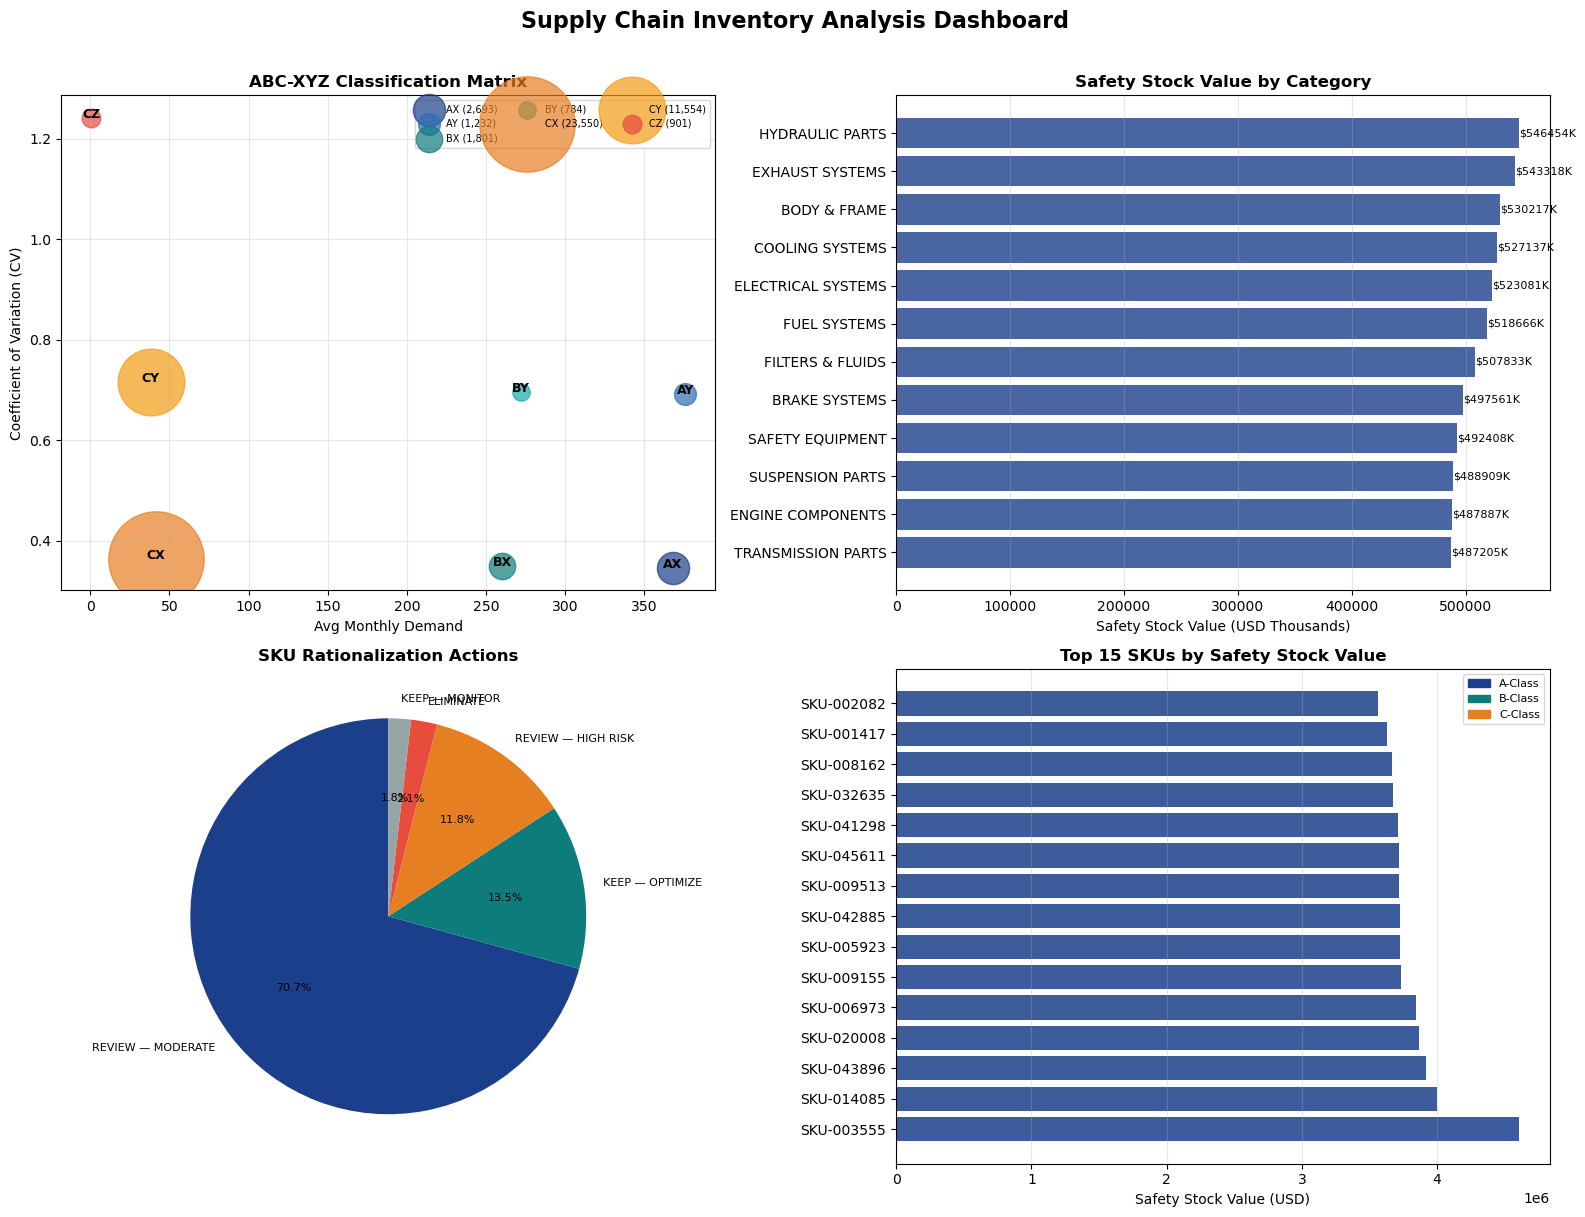

 Chart saved as inventory_dashboard.png


In [15]:
# ── CHARTS ────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Supply Chain Inventory Analysis Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

# ── CHART 1: ABC-XYZ Matrix Bubble Chart ─────────────────────────
ax1 = axes[0, 0]
colors = {'AX':'#1B3F8B','AY':'#2E6DB4','AZ':'#5B9BD5',
          'BX':'#0E7C7B','BY':'#15A8A7','BZ':'#52C5C4',
          'CX':'#E67E22','CY':'#F39C12','CZ':'#E74C3C'}

for cls, grp in df_sorted.groupby('MATRIX_CLASS'):
    ax1.scatter(
        grp['AVG_MONTHLY_DEMAND'].mean(),
        grp['CV'].mean(),
        s=grp.shape[0]/5,
        alpha=0.7,
        color=colors.get(cls,'gray'),
        label=f"{cls} ({grp.shape[0]:,})"
    )
    ax1.annotate(cls,
        (grp['AVG_MONTHLY_DEMAND'].mean(),
         grp['CV'].mean()),
        fontsize=9, fontweight='bold', ha='center'
    )

ax1.set_xlabel('Avg Monthly Demand')
ax1.set_ylabel('Coefficient of Variation (CV)')
ax1.set_title('ABC-XYZ Classification Matrix', fontweight='bold')
ax1.legend(fontsize=7, ncol=3)
ax1.grid(True, alpha=0.3)

# ── CHART 2: Safety Stock Value by Category ───────────────────────
ax2 = axes[0, 1]
cat_ss = df_sorted.groupby('CATEGORY')[
    'SAFETY_STOCK_VALUE_USD'
].sum().sort_values(ascending=True)

bars = ax2.barh(cat_ss.index, cat_ss.values/1000,
                color='#1B3F8B', alpha=0.8)
ax2.set_xlabel('Safety Stock Value (USD Thousands)')
ax2.set_title('Safety Stock Value by Category', fontweight='bold')
for bar, val in zip(bars, cat_ss.values):
    ax2.text(val/1000 + 0.1, bar.get_y() + bar.get_height()/2,
             f'${val/1000:.0f}K', va='center', fontsize=8)
ax2.grid(True, alpha=0.3, axis='x')

# ── CHART 3: Rationalization Action Distribution ──────────────────
ax3 = axes[1, 0]
action_counts = df_sorted['RECOMMENDED_ACTION'].value_counts()
colors_pie = ['#1B3F8B','#0E7C7B','#E67E22','#E74C3C','#95A5A6']
wedges, texts, autotexts = ax3.pie(
    action_counts.values,
    labels=action_counts.index,
    colors=colors_pie[:len(action_counts)],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 8}
)
ax3.set_title('SKU Rationalization Actions', fontweight='bold')

# ── CHART 4: Top 15 SKUs by Safety Stock Value ────────────────────
ax4 = axes[1, 1]
top15 = df_sorted.nlargest(15, 'SAFETY_STOCK_VALUE_USD')[
    ['SKU_ID','SAFETY_STOCK_VALUE_USD','ABC_CALCULATED']
]
bar_colors = ['#1B3F8B' if a=='A'
              else '#0E7C7B' if a=='B'
              else '#E67E22'
              for a in top15['ABC_CALCULATED']]
ax4.barh(top15['SKU_ID'], top15['SAFETY_STOCK_VALUE_USD'],
         color=bar_colors, alpha=0.85)
ax4.set_xlabel('Safety Stock Value (USD)')
ax4.set_title('Top 15 SKUs by Safety Stock Value', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

legend_patches = [
    mpatches.Patch(color='#1B3F8B', label='A-Class'),
    mpatches.Patch(color='#0E7C7B', label='B-Class'),
    mpatches.Patch(color='#E67E22', label='C-Class')
]
ax4.legend(handles=legend_patches, fontsize=8)

plt.tight_layout()
plt.savefig('inventory_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved as inventory_dashboard.png")

In [19]:
# ── SAVE INVENTORY RESULTS TO SNOWFLAKE ──────────────────────────
from snowflake.connector.pandas_tools import write_pandas

cursor = conn.cursor()

# Prepare dataframe for upload
inv_results = df_sorted[[
    'SKU_ID','ABC_CLASS','XYZ_CLASS','COMBINED_CLASS',
    'MATRIX_CLASS','UNIT_COST_USD','LEAD_TIME_DAYS',
    'AVG_MONTHLY_DEMAND','STDDEV_DEMAND','SAFETY_STOCK_UNITS',
    'SAFETY_STOCK_VALUE_USD','REORDER_POINT_UNITS',
    'REORDER_VALUE_USD','DAYS_OF_SUPPLY','INV_TURNOVER',
    'FILL_RATE_PCT','CV','RECOMMENDED_ACTION',
    'TOTAL_DEMAND_VALUE','ZERO_DEMAND_MONTHS'
]].copy()

# Fix data types
for col in inv_results.select_dtypes(include=['float64']).columns:
    inv_results[col] = inv_results[col].round(2)

inv_results.columns = [c.upper() for c in inv_results.columns]

# Create table
cursor.execute("""
    CREATE OR REPLACE TABLE SUPPLY_CHAIN_DB.CURATED.INVENTORY_OPTIMIZATION (
        SKU_ID                  VARCHAR(20),
        ABC_CLASS               VARCHAR(1),
        XYZ_CLASS               VARCHAR(1),
        COMBINED_CLASS          VARCHAR(2),
        MATRIX_CLASS            VARCHAR(2),
        UNIT_COST_USD           FLOAT,
        LEAD_TIME_DAYS          INT,
        AVG_MONTHLY_DEMAND      FLOAT,
        STDDEV_DEMAND           FLOAT,
        SAFETY_STOCK_UNITS      INT,
        SAFETY_STOCK_VALUE_USD  FLOAT,
        REORDER_POINT_UNITS     INT,
        REORDER_VALUE_USD       FLOAT,
        DAYS_OF_SUPPLY          FLOAT,
        INV_TURNOVER            FLOAT,
        FILL_RATE_PCT           FLOAT,
        CV                      FLOAT,
        RECOMMENDED_ACTION      VARCHAR(50),
        TOTAL_DEMAND_VALUE      FLOAT,
        ZERO_DEMAND_MONTHS      INT
    )
""")
print("Table created!")

# Upload
success, nchunks, nrows, _ = write_pandas(
    conn=conn,
    df=inv_results,
    table_name='INVENTORY_OPTIMIZATION',
    database='SUPPLY_CHAIN_DB',
    schema='CURATED'
)

print(f"✅ Inventory results saved to Snowflake!")
print(f"   Rows uploaded : {nrows:,}")

# Final verification in Snowflake
cursor.execute("""
    SELECT
        RECOMMENDED_ACTION,
        COUNT(*)                        AS SKU_COUNT,
        ROUND(SUM(SAFETY_STOCK_VALUE_USD),0) AS SS_VALUE_USD
    FROM SUPPLY_CHAIN_DB.CURATED.INVENTORY_OPTIMIZATION
    GROUP BY RECOMMENDED_ACTION
    ORDER BY SKU_COUNT DESC
""")

results = cursor.fetchall()
print(f"\nFINAL VERIFICATION IN SNOWFLAKE:")
print(f"{'Action':<30} {'SKUs':>10} {'SS Value USD':>15}")
print("-"*57)
for row in results:
    print(f"{row[0]:<30} {row[1]:>10,} {row[2]:>15,.0f}")

print(f"\n Phase 6 — Inventory & SKU Rationalization COMPLETE")

Table created!
✅ Inventory results saved to Snowflake!
   Rows uploaded : 42,515

FINAL VERIFICATION IN SNOWFLAKE:
Action                               SKUs    SS Value USD
---------------------------------------------------------
REVIEW — MODERATE                  30,070     577,542,385
KEEP — OPTIMIZE                     5,726   5,009,558,974
REVIEW — HIGH RISK                  5,034       1,417,343
ELIMINATE                             901          38,771
KEEP — MONITOR                        784     562,119,775

 Phase 6 — Inventory & SKU Rationalization COMPLETE
